# Stage 4: Differential Feature Discovery

**Version**: V4.7

### Input Data (from Stage 2)
- `discovery_data_corrected`: Batch-corrected discovery cohort data
- `discovery_group`: Group information

### Output Data (stage4_differential_results.pkl)
- `sig_taxa`, `sig_pathways`, `sig_genes`, `sig_ecs`: Lists of significantly differential features


## 4.1 Environment Initialization and Data Loading

In [28]:
# ============================================================
# Cell 1: Initialization and data loading
# ============================================================
import os
import pickle
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
    print("✓ Google Drive 已挂载")

# 1. Define paths
BASE_PATH = '/content/drive/MyDrive/ASD_Research'
DATA_PATH = os.path.join(BASE_PATH, '02_merged_data')
FIG_PATH = os.path.join(BASE_PATH, '04_figures')

# Ensure the output directory exists
os.makedirs(FIG_PATH, exist_ok=True)

# 2. Load Stage 2 data
pkl_path = os.path.join(DATA_PATH, 'stage2_normalized_data.pkl')

if os.path.exists(pkl_path):
    print(f"正在加载数据: {pkl_path}")
    with open(pkl_path, 'rb') as f:
        stage2_data = pickle.load(f)

    # Extract key variables (with unified names)
    discovery_data_corrected = stage2_data['discovery_data_corrected'] # CLR校正后数据
    discovery_group = stage2_data['discovery_group']                   # 分组信息

    print("✓ 数据加载成功")
    print(f"  - 样本量: {len(discovery_group)}")
    print(f"  - 数据类型: {list(discovery_data_corrected.keys())}")
else:
    raise FileNotFoundError(f"❌ 找不到文件: {pkl_path}，请检查路径或先运行 Stage 2。")

正在加载数据: /content/drive/MyDrive/ASD_Research/02_merged_data/stage2_normalized_data.pkl
✓ 数据加载成功
  - 样本量: 471
  - 数据类型: ['taxa', 'pathways', 'genes', 'ecs']


## 4.2 Define Core Analysis Functions

In [29]:
# ============================================================
# Cell 2: Define core functions (cleaning + statistics)
# ============================================================

def filter_to_species(df):
    """
    仅保留 's__' (种) 层级，去除 't__' (株) 及更高级别。
    并清洗索引名称，去除前缀。
    """
    # 1. Filtering rule: include 's__' and exclude 't__'
    species_indices = [idx for idx in df.index if 's__' in idx and 't__' not in idx]

    if len(species_indices) == 0:
        print("  ⚠ 警告: 未检测到 's__' 标记，可能数据已经是清洗过的或格式不同")
        return df

    df_species = df.loc[species_indices]

    # 2. Rename indices (remove the s__ prefix and replace underscores with spaces)
    # Example: s__Bacteroides_fragilis -> Bacteroides fragilis
    new_index = [name.split('s__')[-1].replace('_', ' ') for name in df_species.index]
    df_species.index = new_index

    return df_species

def differential_analysis_rigorous(data_df, group_series, alpha=0.05, data_type='clr'):
    """
    执行差异分析：Wilcoxon秩和检验 + FDR校正 + 正确的Log2FC计算 (CLR模式)
    """
    if data_df is None or data_df.empty:
        return None, []

    # Align data
    common_samples = data_df.columns.intersection(group_series.index)
    data_aligned = data_df[common_samples]
    group_aligned = group_series.loc[common_samples]

    asd_samples = group_aligned[group_aligned == 'ASD'].index
    td_samples = group_aligned[group_aligned == 'TD'].index

    results = []

    for feature in data_aligned.index:
        asd_values = data_aligned.loc[feature, asd_samples]
        td_values = data_aligned.loc[feature, td_samples]

        # 1. Statistical test (Mann-Whitney U)
        try:
            stat, pval = stats.mannwhitneyu(asd_values, td_values, alternative='two-sided')
        except ValueError:
            pval = 1.0 # 方差为0的情况

        # 2. Compute Log2FC
        mean_asd = asd_values.mean()
        mean_td = td_values.mean()

        if data_type == 'clr':
            # CLR data are already in log space, so fold change is the difference in means
            log2fc = mean_asd - mean_td
        else:
            # Raw data mode (fallback)
            pseudocount = 1e-9
            log2fc = np.log2((mean_asd + pseudocount) / (mean_td + pseudocount))

        results.append({
            'Feature': feature,
            'Mean_ASD': mean_asd,
            'Mean_TD': mean_td,
            'Log2FC': log2fc,
            'P_value': pval
        })

    results_df = pd.DataFrame(results)

    # 3. FDR correction
    pvals = results_df['P_value'].fillna(1.0)
    _, qvals, _, _ = multipletests(pvals, method='fdr_bh')
    results_df['Q_value'] = qvals

    # 4. Select significant features (only Q < alpha)
    sig_df = results_df[results_df['Q_value'] < alpha]
    sig_features = sig_df['Feature'].tolist()

    return results_df.sort_values('Q_value'), sig_features

print("✓ 核心函数定义完成 (filter_to_species, differential_analysis_rigorous)")

✓ 核心函数定义完成 (filter_to_species, differential_analysis_rigorous)


## 4.3 Run the Analysis (Strict Mode)

In [30]:
# ============================================================
# Cell 3: Run differential analysis (strict strategy only)
# ============================================================
print("=" * 60)
print("🚀 执行 Stage 4 分析：严格模式 (仅保留 FDR Q < 0.05)")
print("=" * 60)

# Initialize containers
diff_results_all = {}
sig_features_strict = {}    # Q < 0.05
sig_features_candidate = {} # 本次策略：将完全等于 sig_features_strict

summary_rows = [] # 用于生成统计表

for dtype in ['taxa', 'pathways', 'genes', 'ecs']:
    print(f"\n>> 正在分析: {dtype} ...")

    df = discovery_data_corrected.get(dtype)

    if df is not None:
        # 1. Special cleaning for the Taxa layer
        if dtype == 'taxa':
            original_n = len(df)
            df = filter_to_species(df)
            print(f"   [清洗] 原始特征: {original_n} -> 保留物种: {len(df)}")

        # 2. Run differential analysis (CLR mode)
        res_df, strict_list = differential_analysis_rigorous(
            df,
            discovery_group,
            alpha=0.05,
            data_type='clr'
        )
        diff_results_all[dtype] = res_df

        # 3. Lock the feature list
        # Core strategy: the Stage 5 candidate list equals the strict list
        sig_features_strict[dtype] = strict_list
        sig_features_candidate[dtype] = strict_list

        # 4. Collect statistics
        n_strict = len(strict_list)
        if n_strict > 0:
            strict_df = res_df[res_df['Q_value'] < 0.05]
            n_asd = len(strict_df[strict_df['Log2FC'] > 0])
            n_td = len(strict_df[strict_df['Log2FC'] < 0])
        else:
            n_asd = 0
            n_td = 0

        print(f"   ✅ 最终选定特征: {n_strict} 个 (ASD↑: {n_asd}, TD↑: {n_td})")

        # Add to the summary table data
        summary_rows.append({
            'Feature Level': dtype,
            'Total Features': len(df),
            'Strict Sig (Q<0.05)': n_strict,
            'ASD Enriched (↑)': n_asd,
            'TD Enriched (↓)': n_td
        })

    else:
        print(f"   ⚠ {dtype} 数据缺失")

print("\n✓ 分析完成")

🚀 执行 Stage 4 分析：严格模式 (仅保留 FDR Q < 0.05)

>> 正在分析: taxa ...
   [清洗] 原始特征: 1658 -> 保留物种: 542
   ✅ 最终选定特征: 4 个 (ASD↑: 0, TD↑: 4)

>> 正在分析: pathways ...
   ✅ 最终选定特征: 4 个 (ASD↑: 0, TD↑: 4)

>> 正在分析: genes ...
   ✅ 最终选定特征: 5 个 (ASD↑: 4, TD↑: 1)

>> 正在分析: ecs ...
   ✅ 最终选定特征: 4 个 (ASD↑: 0, TD↑: 4)

✓ 分析完成


## 4.4 Generate and Display the Summary Table

In [31]:
# ============================================================
# Cell 4: Generate the statistical summary table
# ============================================================
summary_table = pd.DataFrame(summary_rows)
summary_table.set_index('Feature Level', inplace=True)

print("\n【Stage 4 差异分析统计汇总表 (Strict Mode)】")
try:
    from tabulate import tabulate
    print(tabulate(summary_table, headers='keys', tablefmt='psql'))
except ImportError:
    print(summary_table)

# Save the table
csv_path = os.path.join(DATA_PATH, 'stage4_summary_strict.csv')
summary_table.to_csv(csv_path)
print(f"\n✓ 表格已保存至: {csv_path}")


【Stage 4 差异分析统计汇总表 (Strict Mode)】
+-----------------+------------------+-----------------------+--------------------+-------------------+
| Feature Level   |   Total Features |   Strict Sig (Q<0.05) |   ASD Enriched (↑) |   TD Enriched (↓) |
|-----------------+------------------+-----------------------+--------------------+-------------------|
| taxa            |              542 |                     4 |                  0 |                 4 |
| pathways        |              433 |                     4 |                  0 |                 4 |
| genes           |            37334 |                     5 |                  4 |                 1 |
| ecs             |             1682 |                     4 |                  0 |                 4 |
+-----------------+------------------+-----------------------+--------------------+-------------------+

✓ 表格已保存至: /content/drive/MyDrive/ASD_Research/02_merged_data/stage4_summary_strict.csv


## 4.5 Volcano Plot Visualization

正在绘制 taxa ...


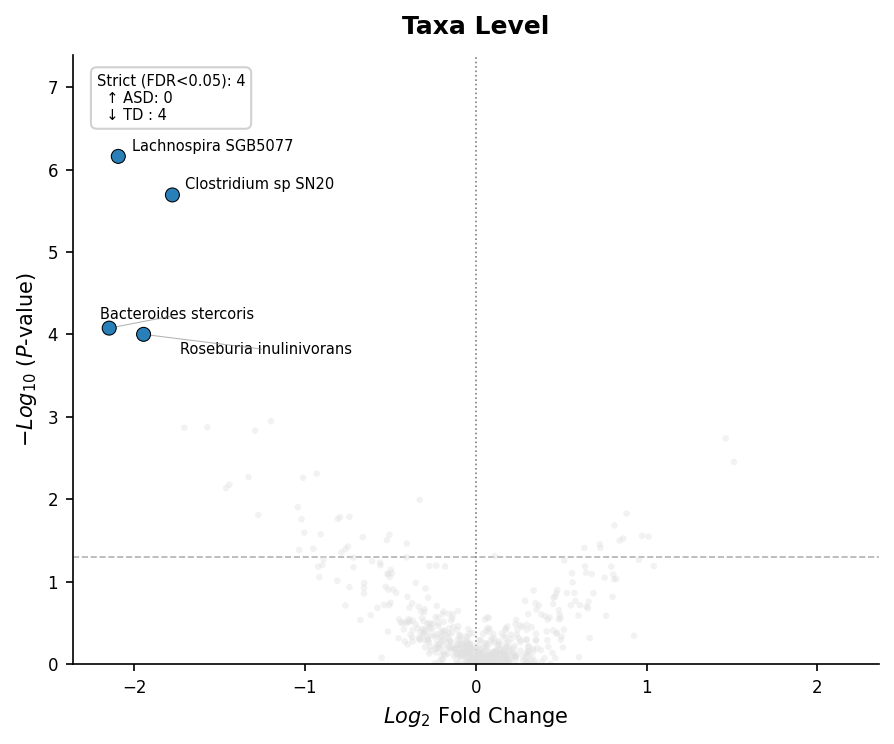

正在绘制 pathways ...


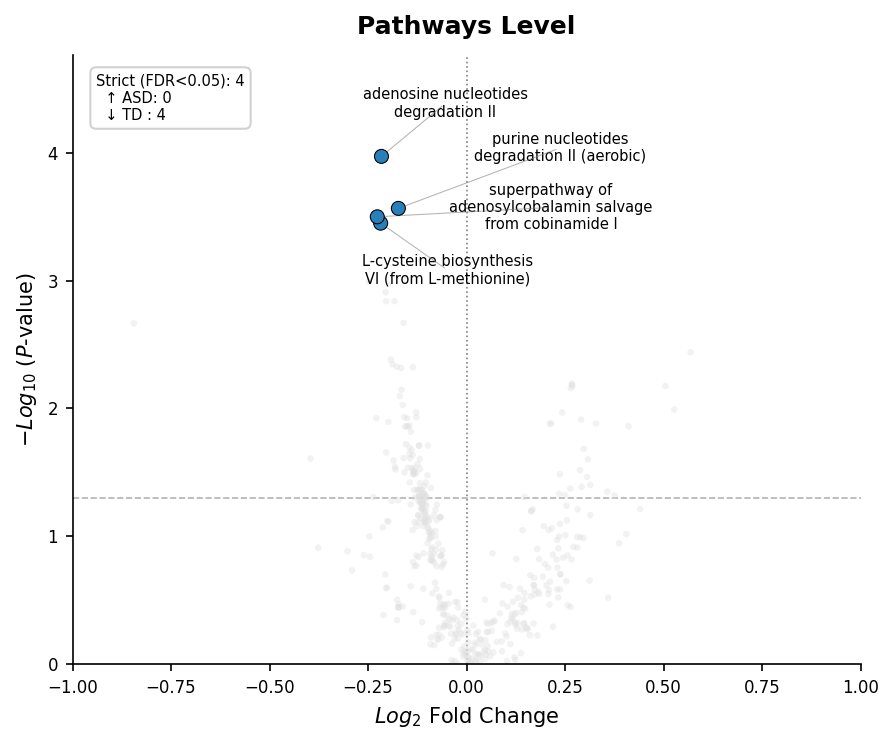

正在绘制 genes ...


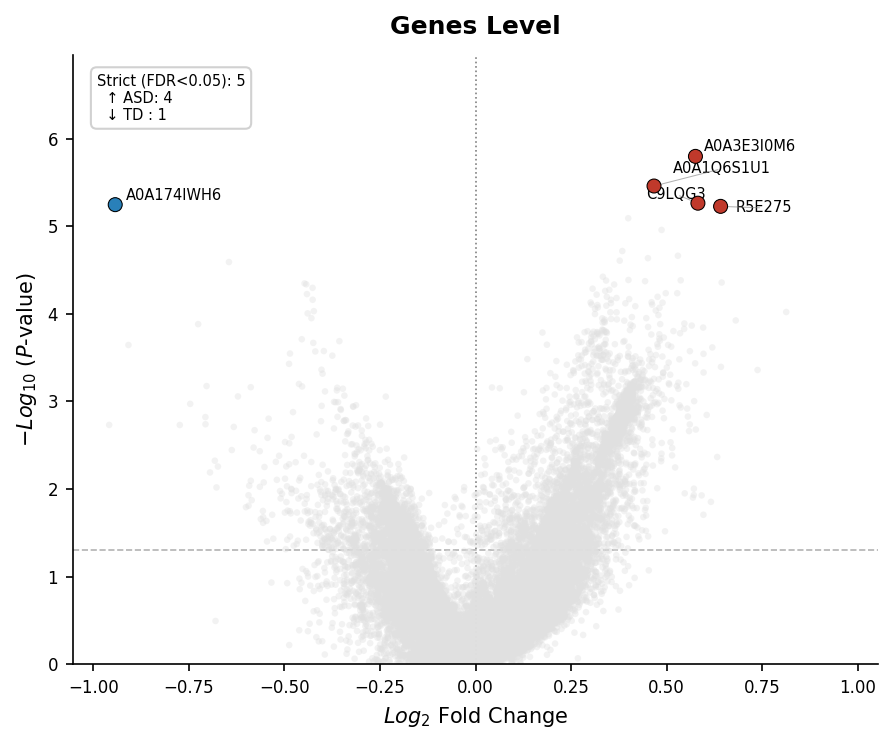

正在绘制 ecs ...


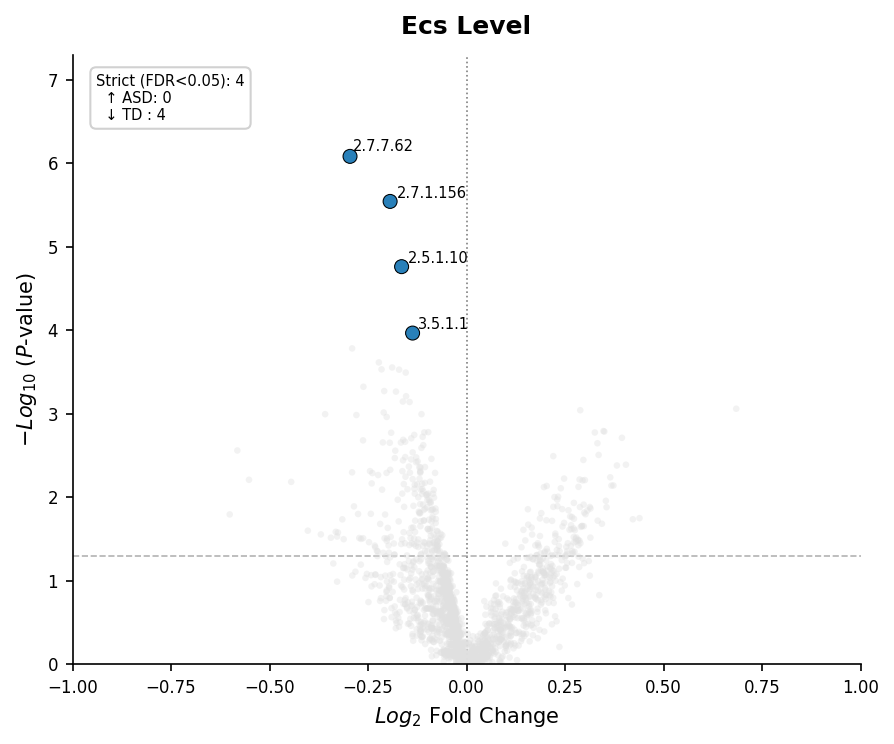

In [32]:
# ============================================================
# Cell 5: Draw volcano plots (single-panel, Nature style, with smart annotation)
# ============================================================
# Automatically install dependencies
try:
    import adjustText
except ImportError:
    !pip install adjustText -q
    import adjustText
from adjustText import adjust_text
import textwrap

# Plot parameter settings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size'] = 8
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['figure.dpi'] = 150

def plot_single_volcano(df, dtype, output_dir):
    if df is None or df.empty: return

    df = df.copy()
    df['logP'] = -np.log10(df['P_value'] + 1e-10)

    # Canvas settings
    fig, ax = plt.subplots(figsize=(6, 5))

    # Color settings
    colors = np.array(['#E0E0E0'] * len(df), dtype=object)
    alphas = np.array([0.4] * len(df))
    sizes = np.array([10] * len(df))

    # Q < 0.05 (strict) - highlighted with dark colors
    mask_strict = df['Q_value'] < 0.05
    colors[mask_strict & (df['Log2FC'] > 0)] = '#C0392B' # 深红
    colors[mask_strict & (df['Log2FC'] < 0)] = '#2980B9' # 深蓝
    alphas[mask_strict] = 1.0
    sizes[mask_strict] = 45

    # Plot
    ax.scatter(df['Log2FC'], df['logP'], c=colors, s=sizes, alpha=alphas, edgecolors='none', zorder=1)
    ax.scatter(df[mask_strict]['Log2FC'], df[mask_strict]['logP'],
               c=colors[mask_strict], s=sizes[mask_strict],
               alpha=1.0, edgecolors='black', linewidth=0.5, zorder=4)

    # Reference lines
    ax.axhline(-np.log10(0.05), color='gray', linestyle='--', linewidth=0.8, alpha=0.6, zorder=0)
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.8, zorder=0)

    # Axis ranges
    max_fc = df['Log2FC'].abs().max()
    xlim = max(1, max_fc * 1.1)
    ax.set_xlim(-xlim, xlim)
    ylim = df['logP'].max() * 1.2
    ax.set_ylim(0, ylim)

    # Statistics box
    n_strict_up = np.sum(mask_strict & (df['Log2FC'] > 0))
    n_strict_down = np.sum(mask_strict & (df['Log2FC'] < 0))
    stats_text = f"Strict (FDR<0.05): {n_strict_up + n_strict_down}\n  ↑ ASD: {n_strict_up}\n  ↓ TD : {n_strict_down}"
    legend_box = ax.text(0.03, 0.97, stats_text, transform=ax.transAxes, fontsize=7, verticalalignment='top',
                         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='#CCCCCC'), zorder=5)

    # Smart annotation
    texts = []
    sig_df = df[mask_strict].sort_values('P_value')
    for idx, row in sig_df.iterrows():
        raw_name = row['Feature']
        # Name-cleaning logic
        if dtype == 'taxa':
            clean_name = raw_name.split('|')[-1].replace('s__', '').replace('t__', '').replace('_', ' ')
        elif dtype == 'pathways':
            clean_name = raw_name.split(':', 1)[1].strip() if ':' in raw_name else raw_name
            clean_name = textwrap.fill(clean_name, width=25)
        elif dtype == 'genes':
            clean_name = raw_name.replace('UniRef90_', '')
        else:
            clean_name = raw_name

        texts.append(ax.text(row['Log2FC'], row['logP'], clean_name, fontsize=7, color='black'))

    if texts:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.6, lw=0.5),
                    force_points=0.5, force_text=0.6, expand_points=(1.5, 1.5), expand_text=(1.2, 1.2),
                    add_objects=[legend_box])

    # Styling and save
    ax.set_xlabel(r'$Log_2$ Fold Change', fontsize=10)
    ax.set_ylabel(r'$-Log_{10}$ ($P$-value)', fontsize=10)
    ax.set_title(f"{dtype.capitalize()} Level", fontweight='bold', pad=10)
    sns.despine(ax=ax)
    plt.tight_layout()

    filename = f'Fig3A_Volcano_{dtype.capitalize()}.png'
    plt.savefig(os.path.join(FIG_PATH, filename), dpi=300, bbox_inches='tight')
    plt.show()

# Plot in a loop
print("=" * 60)
for dtype in ['taxa', 'pathways', 'genes', 'ecs']:
    if dtype in diff_results_all:
        print(f"正在绘制 {dtype} ...")
        plot_single_volcano(diff_results_all[dtype], dtype, FIG_PATH)

## 4.6 Save Final Results

In [33]:
# ============================================================
# Cell 6: Save results for Stage 5
# ============================================================
stage4_results = {
    'diff_results': diff_results_all,             # 完整统计表
    'sig_features_strict': sig_features_strict,   # 严格列表 (Q<0.05)
    'sig_features_candidate': sig_features_candidate, # 同样是 Q<0.05 (供机器学习)
    'metadata': {'method': 'Wilcoxon_FDR_CLR', 'strategy': 'Strict_Only'}
}

save_path = os.path.join(DATA_PATH, 'stage4_diff_results.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(stage4_results, f)

print(f"\n" + "="*60)
print(f"✓ Stage 4 最终结果已保存至: {save_path}")
print(f"  Stage 5 机器学习将使用以下特征数量进行建模:")
print(f"  - Taxa:     {len(sig_features_candidate['taxa'])}")
print(f"  - Pathways: {len(sig_features_candidate['pathways'])}")
print(f"  - Genes:    {len(sig_features_candidate['genes'])}")
print(f"  - ECs:      {len(sig_features_candidate['ecs'])}")
print(f"  总计:       {sum(len(v) for v in sig_features_candidate.values())} 个特征")


✓ Stage 4 最终结果已保存至: /content/drive/MyDrive/ASD_Research/02_merged_data/stage4_diff_results.pkl
  Stage 5 机器学习将使用以下特征数量进行建模:
  - Taxa:     4
  - Pathways: 4
  - Genes:    5
  - ECs:      4
  总计:       17 个特征
